# COSC2753 Assignment 2 - Fashion Intelligence System
## Task 2 - `season` Classification
### Objective: Develop a model to predict "season" class


## Part I - Load the preprocessed data

### What is loaded, and what is rebuilt

Loaded straight from save:

| Artifact | File |
|---|---|
| Full cleaned train/validation split | "train_full.csv", "val_full.csv" |
| Per-task usable subsets (target non-null, encoded) | "holdout_metadata/{target}_{train,val}.csv" |
| Fitted "LabelEncoder" per target | "label_encoders.pkl" |
| Image size, normalisation constants, thresholds, seed | "pipeline_config.json" |

Rebuilt in code, because they are not serialisable objects:

- "train_transform" / "eval_transform" - torchvision transforms hold a lambda-free but
  still unpicklable graph. They are reconstructed from the "normalization_mean" and
  "normalization_std" recorded in "pipeline_config.json", so they are numerically identical
  to the ones used to compute those statistics, not merely similar.
- "FashionImageDataset", "get_weighted_sampler" - ordinary class and function definitions.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]
Rare-class thresholds: articleType>=20, usage>=100


In [2]:
# dtype={'id': str} is load-bearing -- see the note above.
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28371, 13)   val_full: (9457, 13)   combined: (37828, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28371  val=  9455  classes= 95
  season       -> column season               train= 28357  val=  9451  classes=  4
  gender       -> column gender               train= 28371  val=  9457  classes=  5
  usage        -> column usage_grouped        train= 28315  val=  9442  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II - Task 2

## Task 2: Fashion season classification

In [4]:
# season rows from the single shared masterCategory-stratified split (not a separate split). Already contain season_enc.
task2_train = train_usable['season'].copy()
task2_val = val_usable['season'].copy()

assert 'season_enc' in task2_train.columns
assert 'season_enc' in task2_val.columns
print(f'Task 2 train: {len(task2_train):,}; validation: {len(task2_val):,}')
print('Season classes:', encoders['season'].classes_.tolist())

Task 2 train: 28,357; validation: 9,451
Season classes: ['Fall', 'Spring', 'Summer', 'Winter']


In [5]:
print(task2_train.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'articleType_grouped', 'usage_grouped', 'season_enc']


### a) Tabular data preprocessing

Image preprocessing will be the same as task 1  
Metadata needs to be pre-processed since it was used in multi-input models. For categorical attributes, missing values will be imputed using mode. Then the data will be encoded using one-hot encoder [REFERENCE HERE]. On the other hand, categorical data will go through mode imputation. The target attribute “season” had 13 missing values and will be dropped instead of imputed. This was done to make sure no artificial bias will be introduced into the dataset. The target attribute is then encoded to numerical label so machine learning models can predict them.  


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import joblib

TASK2_TARGET = 'season'
META_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
META_CAT = [c for c in META_FEATURES if c != 'year']
META_NUM = ['year']

assert task2_train[TASK2_TARGET].notna().all() and task2_val[TASK2_TARGET].notna().all()
assert set(task2_val[TASK2_TARGET]).issubset(set(task2_train[TASK2_TARGET]))

X_train = task2_train[META_FEATURES].copy()
X_val = task2_val[META_FEATURES].copy()
# Convert pandas nullable values to NumPy-compatible missing values for sklearn.
for frame in (X_train, X_val):
    for col in META_CAT:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')

# Single preprocessor shared by BOTH the tabular baseline and the multi-input deep model,
# so there's one source of truth for how metadata gets encoded.
meta_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM)
])
meta_train = meta_preprocessor.fit_transform(X_train).astype('float32')
meta_val = meta_preprocessor.transform(X_val).astype('float32')

# Reuse the season encoder already fit in Section 6.5 -- no need for a second one.
season_encoder = encoders['season']
y_train = task2_train['season_enc'].to_numpy()
y_val = task2_val['season_enc'].to_numpy()

print('Metadata train shape:', meta_train.shape)
print('Metadata validation shape:', meta_val.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

Metadata train shape: (28357, 227)
Metadata validation shape: (9451, 227)
Encoded target shapes: (28357,) (9451,)


The preprocessing step was compiled into a sklearn Pipeline to ensure that we can use them for train split with .fit_transform() and validation split with .transform(). This ensure that no data leakage will appear during the pre-processing step. To deal with imbalanced classes, WeightedRandomSampler was used during training to ensure batches are more balanced across classes.

### b) Model choice and comparison:
#### 1. Baseline model testing:

Before implementing multi-input models, we train and test two baseline models, one for each type of datatype. We used Logistic Regression to predict using only metadata due to its simplicity while maintaining a fair baseline performance [REFERENCE HERE]. ResNet18 was used for image-only data of dataset because it have high accuracy while still being lightweight and fast [REFERENCE HERE].

#### 1a. Ablation testing to see which feature is good for metadata prediction:

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Group your features into logical units
FEATURE_GROUPS = {
    'gender': ['gender'],
    'masterCategory': ['masterCategory'],
    'subCategory': ['subCategory'],
    'articleType': ['articleType'],
    'baseColour': ['baseColour'],
    'usage': ['usage'],
    'year': ['year'],
    'productDisplayName': ['productDisplayName'],
}


def run_rf_ablation(name, train_matrix, val_matrix):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_train)
    train_f1 = f1_score(y_train, model.predict(train_matrix), average='macro')
    val_f1 = f1_score(y_val, model.predict(val_matrix), average='macro')
    print(f'{name:42s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1

def build_metadata_matrix_groups(train_df, val_df, active_groups, text_max_features=300):
    """Generalised version of build_metadata_matrix: builds the design matrix using only
    the feature groups listed in `active_groups`, instead of hardcoded year/text toggles."""
    cat_features = [col for grp in active_groups for col in FEATURE_GROUPS[grp] if col in META_CAT]
    num_features = ['year'] if 'year' in active_groups else []
    text_col = ['productDisplayName'] if 'productDisplayName' in active_groups else []

    transformers = []
    if cat_features:
        transformers.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features))
    if num_features:
        transformers.append(('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_features))
    if text_col:
        transformers.append(('text', TfidfVectorizer(max_features=text_max_features, stop_words='english'),
                              'productDisplayName'))

    if not transformers:
        raise ValueError("At least one feature group must be selected.")

    preprocessor = ColumnTransformer(transformers)

    cols = cat_features + num_features + text_col
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    for col in cat_features:
        Xtr[col] = Xtr[col].astype(object).where(Xtr[col].notna(), np.nan)
        Xva[col] = Xva[col].astype(object).where(Xva[col].notna(), np.nan)
    for col in num_features:
        Xtr[col] = pd.to_numeric(Xtr[col], errors='coerce')
        Xva[col] = pd.to_numeric(Xva[col], errors='coerce')
    for col in text_col:
        Xtr[col] = Xtr[col].astype(object).fillna('Unknown')
        Xva[col] = Xva[col].astype(object).fillna('Unknown')

    Mtr = preprocessor.fit_transform(Xtr).astype('float32')
    Mva = preprocessor.transform(Xva).astype('float32')
    return Mtr, Mva


all_groups = list(FEATURE_GROUPS.keys())
ablation_results = {}

# 1. Full model -- every feature group included
m_tr, m_va = build_metadata_matrix_groups(task2_train, task2_val, active_groups=all_groups)
ablation_results['Full Model (Baseline)'] = run_rf_ablation('Full Model (Baseline)', m_tr, m_va)

# 2. Leave-one-out -- drop each feature group individually
for group_to_drop in all_groups:
    remaining_groups = [g for g in all_groups if g != group_to_drop]
    m_tr, m_va = build_metadata_matrix_groups(task2_train, task2_val, active_groups=remaining_groups)
    label = f'Without {group_to_drop}'
    ablation_results[label] = run_rf_ablation(label, m_tr, m_va)

ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
display(ablation_df.round(4))

Full Model (Baseline)                      train F1: 0.9621  val F1: 0.8679
Without gender                             train F1: 0.9619  val F1: 0.8691
Without masterCategory                     train F1: 0.9623  val F1: 0.8728
Without subCategory                        train F1: 0.9621  val F1: 0.8723
Without articleType                        train F1: 0.9605  val F1: 0.8676
Without baseColour                         train F1: 0.9602  val F1: 0.8731
Without usage                              train F1: 0.9604  val F1: 0.8682
Without year                               train F1: 0.8853  val F1: 0.7633
Without productDisplayName                 train F1: 0.8231  val F1: 0.7715


,Train F1,Validation F1
Full Model (Baseline),0.9621,0.8679
Without gender,0.9619,0.8691
Without masterCategory,0.9623,0.8728
Without subCategory,0.9621,0.8723
Without articleType,0.9605,0.8676
Without baseColour,0.9602,0.8731
Without usage,0.9604,0.8682
Without year,0.8853,0.7633
Without productDisplayName,0.8231,0.7715


Logistic Regression (metadata only) -- train F1: 0.7459, val F1: 0.7286

              precision    recall  f1-score   support

        Fall       0.64      0.88      0.74      2563
      Spring       0.47      0.77      0.59       387
      Summer       0.88      0.63      0.73      4664
      Winter       0.83      0.88      0.85      1837

    accuracy                           0.75      9451
   macro avg       0.70      0.79      0.73      9451
weighted avg       0.79      0.75      0.75      9451



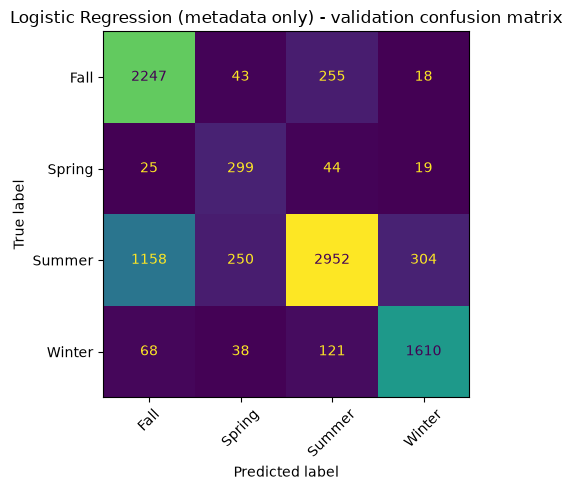

Saved metadata-only baseline to ../data/processed/task2_models


In [ ]:
# Metadata-only baseline: how far do tabular features alone get us on season prediction,
# before we spend effort on the image branch at all?
BASELINE_DIR = OUT_DIR / 'task2_models'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_META_FEATURES = ['gender', 'articleType', 'usage', 'year']
META_CAT_FINAL = [c for c in FINAL_META_FEATURES if c != 'year']
META_NUM_FINAL = ['year']
meta_preprocessor_final = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT_FINAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM_FINAL)
])


X_train_final = task2_train[FINAL_META_FEATURES].copy()
X_val_final = task2_val[FINAL_META_FEATURES].copy()
meta_train_final = meta_preprocessor_final.fit_transform(X_train_final).astype('float32')
meta_val_final = meta_preprocessor_final.transform(X_val_final).astype('float32')

print('Metadata train shape:', meta_train_final.shape)
print('Metadata validation shape:', meta_val_final.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(meta_train_final, y_train)

logreg_train_f1 = f1_score(y_train, logreg.predict(meta_train_final), average='macro')
logreg_val_pred = logreg.predict(meta_val_final)
logreg_val_f1 = f1_score(y_val, logreg_val_pred, average='macro')

print(f'Logistic Regression (metadata only) -- train F1: {logreg_train_f1:.4f}, val F1: {logreg_val_f1:.4f}\n')
print(classification_report(y_val, logreg_val_pred, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, logreg_val_pred, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Logistic Regression (metadata only) - validation confusion matrix')
plt.tight_layout()
plt.show()

joblib.dump(logreg, BASELINE_DIR / 'logreg_metadata_baseline.joblib')
print(f'Saved metadata-only baseline to {BASELINE_DIR}')

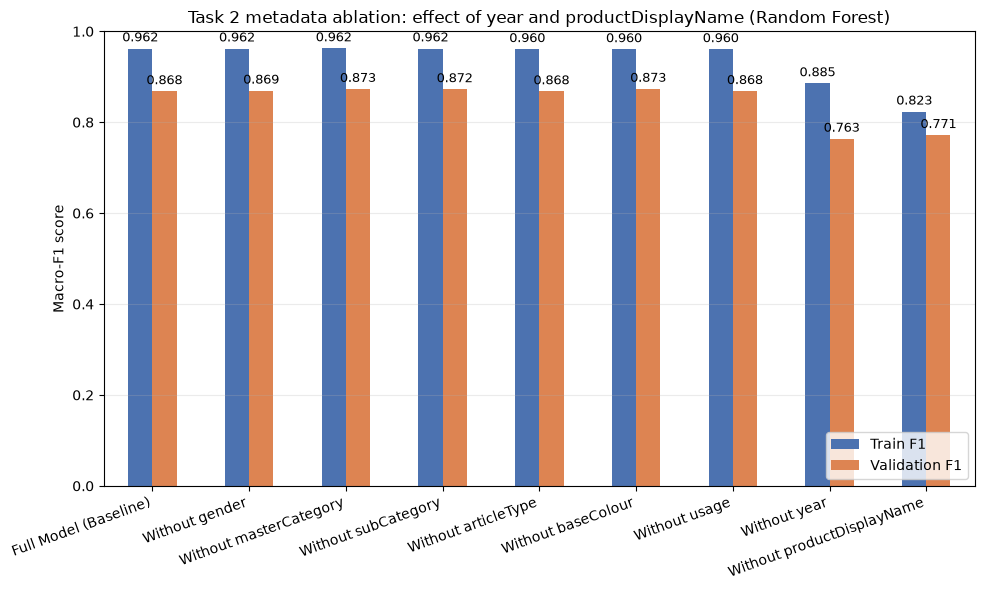

In [9]:
ax = ablation_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score')
plt.title('Task 2 metadata ablation: effect of year and productDisplayName (Random Forest)')
plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 70, 4

sampler = get_weighted_sampler(task2_train, 'season')

class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model

class MultiInputDataset(Dataset):
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame, self.metadata, self.labels = frame.reset_index(drop=True), metadata, labels
        self.image_dir, self.transform = image_dir, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            image = self.transform(im)
        return image, torch.tensor(self.metadata[i].toarray() if hasattr(self.metadata[i], 'toarray') else self.metadata[i], dtype=torch.float32).squeeze(0), torch.tensor(self.labels[i], dtype=torch.long)

# Build datasets and loaders for the multi-input model.
train_ds = MultiInputDataset(task2_train, meta_train_final, y_train, IMAGES_TRAIN_DIR, train_transform)
val_ds = MultiInputDataset(task2_val, meta_val_final, y_val, IMAGES_TRAIN_DIR, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                           persistent_workers=(NUM_WORKERS > 0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         persistent_workers=(NUM_WORKERS > 0))

# Shared loaders for the two image-only comparison models (built once, reused for both
# ResNet18 and MobileNetV3 so workers aren't spun up and torn down twice).
train_ds_img = FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', train_transform)
train_loader_img = DataLoader(train_ds_img, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))
val_loader_img = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
                            batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))

# Create pretrained image-only comparison models and replace their classifiers for season prediction.
def make_pretrained(model_name):
    if model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(season_encoder.classes_))
    else:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(season_encoder.classes_))
    return model.to(DEVICE)

class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor for MultiInputNet --
    the missing cell of the 2x2 grid: pretrained encoder WITH metadata."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class SmallImageEncoder(nn.Module):
    """From-scratch CNN sized for 60x80 images - no aggressive early downsampling."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 60x80 -> 30x40

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 30x40 -> 15x20

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.out_dim = out_dim
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.proj(self.features(x).flatten(1))

class ResNet18Encoder(nn.Module):
    """From-scratch ResNet18 backbone, weights=None - kept as a comparison point
    against SmallImageEncoder to show whether stem downsampling hurts at 60x80."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        self.out_dim = out_dim
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))



class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut matching if channels change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections, SiLU activations, 
    and gradual spatial downsampling for 60x80 images."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        
        self.stage1 = ConvBlock(3, 32)
        self.pool1  = nn.MaxPool2d(2)                            # 60x80 -> 30x40
        
        self.stage2 = ConvBlock(32, 64)
        self.pool2  = nn.MaxPool2d(2)                            # 30x40 -> 15x20
        
        self.stage3 = ConvBlock(64, 128)
        self.pool3  = nn.MaxPool2d(2)                            # 15x20 -> 7x10
        
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)               # 7x10  -> 1x1
        
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.SiLU()
        )

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        x = self.stage4(x)
        
        x = self.global_pool(x).flatten(1)
        return self.proj(x)

# MODIFY: new from-scratch architecture -- see the markdown cell in section 1d.
# No torchvision backbone and no `weights=` argument, so it stays fully self-trained.
import torch.nn.functional as F


class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualEncoder(nn.Module):
    """From-scratch SE-residual encoder sized for 60x80 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8. Unlike ResNet18Encoder there is no
    stride-2 stem or stem max-pool, so no spatial detail is discarded up front."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


class MultiInputNet(nn.Module):
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        image_dim = image_encoder.out_dim
        self.meta_scale = nn.Parameter(torch.tensor(1.0))
        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        
    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata) * self.meta_scale
        fused = torch.cat([img_feats, meta_feats], dim=1)
        return self.head(fused)

In [11]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def to_device(batch):
    """Both loaders end with the label; everything before it is model input.
    (image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata].
    This one line is what lets train_model and train_image_only collapse into one function."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    """One pass over `loader`. Training if `optimiser` is given, eval-only otherwise."""
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)

            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro')


def fit(model, loader_tr, loader_va, model_name='model', patience=15, lr=3e-4, weight_decay=1e-4):
    """Replaces train_model and train_image_only. Same optimiser settings for every
    model (train_image_only used to skip weight_decay -- that was an accident of
    copy-paste, not a deliberate choice, so it's gone now)."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = None
    best_val_loss = None
    best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch + 1}/{EPOCHS}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch + 1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {current_lr:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)

    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch}  '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')

    return model, best_val_f1, best_epoch


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            
            # Keep predictions and labels on GPU as tensors
            preds = model(*inputs).argmax(dim=1)
            
            all_preds.append(preds)
            all_actual.append(labels)
            
    # Concatenate directly on GPU, then transfer to CPU ONCE
    preds_np = torch.cat(all_preds).cpu().numpy()
    actual_np = torch.cat(all_actual).cpu().numpy()
    
    return f1_score(actual_np, preds_np, average='macro')


In [ ]:
# ---- Fusion-method ablation: which way of combining image + metadata features is best? ----
import torch.nn.functional as F

class FusionMultiInputNet(nn.Module):
    """Same idea as MultiInputNet, but the fusion step is swappable so we can
    isolate the effect of *how* image and metadata features are combined,
    keeping the image encoder and metadata branch identical across runs.

    fusion:
      - 'concat' : baseline used elsewhere in the notebook -> [img_feats, meta_feats]
      - 'sum'    : project both branches to the same width and add them
      - 'gated'  : learn a per-sample gate g in [0,1] from both branches,
                   fused = g * img_feats + (1-g) * meta_feats
      - 'film'   : metadata predicts a per-channel scale/shift (gamma, beta)
                   that modulates the image features (FiLM-style conditioning)
    """
    def __init__(self, metadata_dim, n_classes, image_encoder, fusion='concat', hidden=128):
        super().__init__()
        assert fusion in ('concat', 'sum', 'gated', 'film')
        self.fusion = fusion
        self.image = image_encoder
        image_dim = image_encoder.out_dim

        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        if fusion == 'concat':
            fused_dim = image_dim + hidden
        elif fusion == 'sum':
            self.img_proj = nn.Linear(image_dim, hidden)
            fused_dim = hidden
        elif fusion == 'gated':
            self.img_proj = nn.Linear(image_dim, hidden)
            self.gate = nn.Linear(image_dim + hidden, 1)
            fused_dim = hidden
        elif fusion == 'film':
            self.img_proj = nn.Linear(image_dim, hidden)
            self.film = nn.Linear(hidden, 2 * hidden)  # predicts (gamma, beta)
            fused_dim = hidden

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata)

        if self.fusion == 'concat':
            fused = torch.cat([img_feats, meta_feats], dim=1)
        elif self.fusion == 'sum':
            fused = self.img_proj(img_feats) + meta_feats
        elif self.fusion == 'gated':
            img_p = self.img_proj(img_feats)
            g = torch.sigmoid(self.gate(torch.cat([img_feats, meta_feats], dim=1)))
            fused = g * img_p + (1 - g) * meta_feats
        elif self.fusion == 'film':
            img_p = self.img_proj(img_feats)
            gamma, beta = self.film(meta_feats).chunk(2, dim=1)
            fused = img_p * (1 + gamma) + beta

        return self.head(fused)


# Hold the image encoder fixed so the comparison isolates the fusion mechanism,
# not encoder capacity. Swap this for SEResidualEncoder if that ends up winning instead.
FUSION_ENCODER_CLS = ImprovedSmallImageEncoder
FUSION_METHODS = ['concat', 'sum', 'gated', 'film']

fusion_results = {}
fusion_models = {}

for fusion_type in FUSION_METHODS:
    torch.manual_seed(RANDOM_STATE)
    model = FusionMultiInputNet(
        metadata_dim=meta_train_final.shape[1],
        n_classes=len(season_encoder.classes_),
        image_encoder=FUSION_ENCODER_CLS(out_dim=128),
        fusion=fusion_type,
    ).to(DEVICE)

    # Use a smaller patience here (e.g. patience=5) if you just want a quick signal
    # rather than a fully-converged run for every fusion type.
    trained_model, val_f1, best_epoch = fit(
        model, train_loader, val_loader, model_name=f'Fusion-{fusion_type}', patience=8
    )
    fusion_results[fusion_type] = val_f1
    fusion_models[fusion_type] = trained_model

fusion_df = pd.Series(fusion_results, name='Validation macro-F1').sort_values(ascending=False)
print(fusion_df)

ax = fusion_df.plot(kind='bar', figsize=(6, 4), ylim=(0, 1), color='#4C72B0')
plt.ylabel('Macro-F1'); plt.title('Task 2: fusion method comparison'); plt.grid(axis='y', alpha=.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

best_fusion = fusion_df.idxmax()
print(f'Best fusion method: {best_fusion} (val macro-F1 = {fusion_df[best_fusion]:.4f})')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 


ResNet18 (pretrained) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet18 (pretrained) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9350 - val_loss: 1.0328 - train_f1: 0.6646 - val_f1: 0.5993 - lr: 3.00e-04


...

ResNet18 (pretrained) 33/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 33/70 - train_loss: 0.3807 - val_loss: 0.8715 - train_f1: 0.9850 - val_f1: 0.7760 - lr: 9.37e-06


ResNet18 (pretrained) 34/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet18 (pretrained) 34/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 34/70 - train_loss: 0.3809 - val_loss: 0.8661 - train_f1: 0.9855 - val_f1: 0.7780 - lr: 9.37e-06
Early stopping triggered at epoch 34 (best epoch was 19)


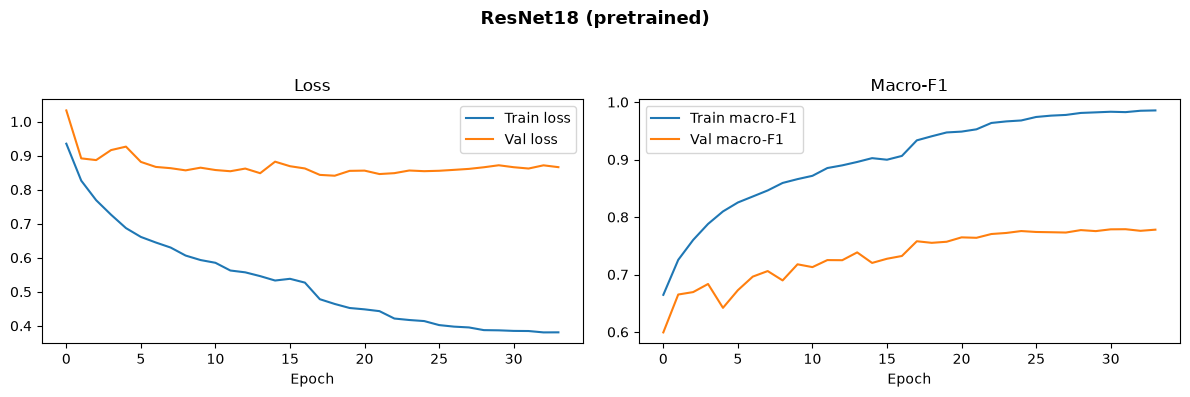

>>> Best checkpoint for ResNet18 (pretrained): epoch 19  (val_loss=0.8410, val_f1=0.7551)


In [12]:
OUTPUT_DIR = Path('../outputs') / 'task2_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(RANDOM_STATE)
results = {}
resnet_model, resnet_f1, resnet_epoch = fit(
    make_pretrained('resnet18'), train_loader_img, val_loader_img, model_name='ResNet18 (pretrained)')
results['ResNet18 (pretrained)'] = (resnet_f1, resnet_epoch)

ResNet18 (pretrained, image only) -- train F1: 0.9449, val F1: 0.7551

              precision    recall  f1-score   support

        Fall       0.71      0.72      0.71      2563
      Spring       0.77      0.73      0.75       387
      Summer       0.81      0.77      0.79      4664
      Winter       0.73      0.80      0.76      1837

    accuracy                           0.76      9451
   macro avg       0.75      0.76      0.76      9451
weighted avg       0.76      0.76      0.76      9451



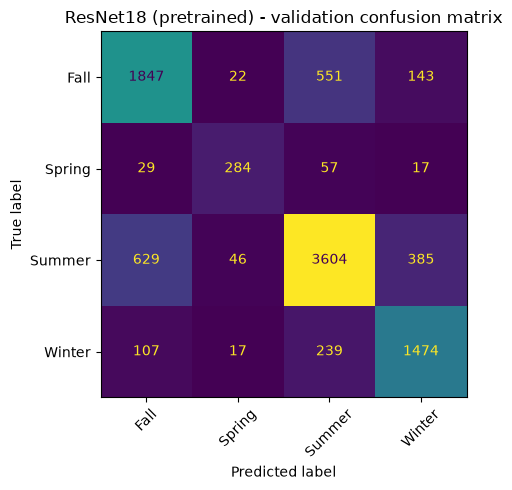

In [13]:
# Testing: ResNet18 (pretrained, image-only) -- same treatment as the metadata-only
# baseline above (val F1, classification report, confusion matrix), so both baselines
# are fully tested here before we move on to the multi-input models.
image_train_loader = DataLoader(
    FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
image_val_loader = DataLoader(
    FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

resnet_train_f1 = evaluate(resnet_model, image_train_loader)

resnet_model.eval()
resnet_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = resnet_model(images).argmax(dim=1).cpu().numpy()
        resnet_val_preds.extend(preds)
resnet_val_preds = np.array(resnet_val_preds)
resnet_val_f1 = f1_score(y_val, resnet_val_preds, average='macro')

print(f'ResNet18 (pretrained, image only) -- train F1: {resnet_train_f1:.4f}, val F1: {resnet_val_f1:.4f}\n')
print(classification_report(y_val, resnet_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, resnet_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ResNet18 (pretrained) - validation confusion matrix')
plt.tight_layout()
plt.show()


#### 1c. ImprovedSmallCNN (image-only)

`styles_prediction.csv` (the real test set) has no metadata at all, so the multi-input model can't run on it directly -- `MultiInputNet` requires both an image and a metadata vector. This image-only version of our chosen encoder (`ImprovedSmallImageEncoder`) is what we actually use for test-set predictions. It's trained and tested here, alongside the other image-only/metadata-only baselines, before the multi-input section.

ImprovedSmallCNN (image-only) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 1.0508 - val_loss: 1.0858 - train_f1: 0.5720 - val_f1: 0.5317 - lr: 3.00e-04


ImprovedSmallCNN (image-only) 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImprovedSmallCNN (image-only) 44/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 44/70 - train_loss: 0.5923 - val_loss: 0.8356 - train_f1: 0.8797 - val_f1: 0.7212 - lr: 5.86e-07


ImprovedSmallCNN (image-only) 45/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 45/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 45/70 - train_loss: 0.5870 - val_loss: 0.8347 - train_f1: 0.8791 - val_f1: 0.7286 - lr: 5.86e-07
Early stopping triggered at epoch 45 (best epoch was 30)


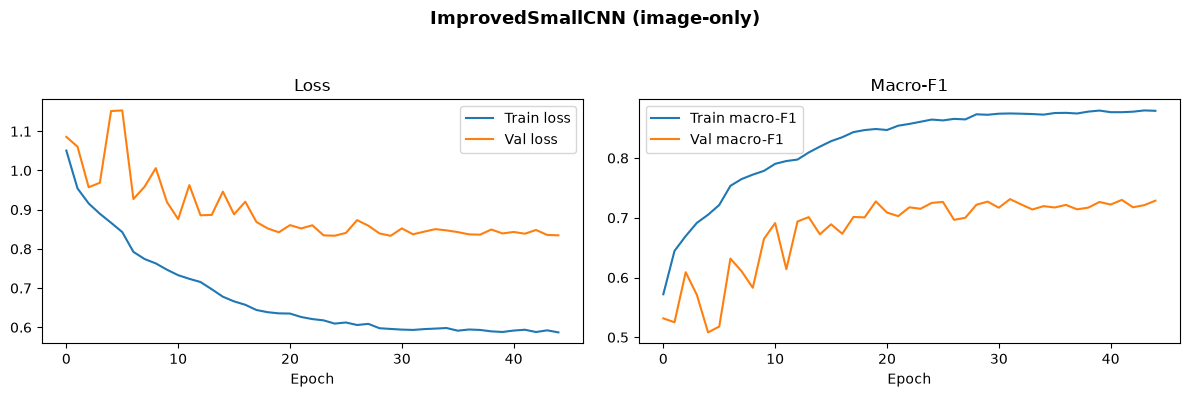

>>> Best checkpoint for ImprovedSmallCNN (image-only): epoch 30  (val_loss=0.8334, val_f1=0.7271)


In [14]:
class ImageOnlyClassifier(nn.Module):
    """An encoder plus a plain linear head -- no metadata branch. Used to get a
    working model for images with no metadata, e.g. the real test set."""
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
improved_small_cnn_img_only_model, improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch = fit(
    ImageOnlyClassifier(ImprovedSmallImageEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='ImprovedSmallCNN (image-only)')
results['ImprovedSmallCNN (image-only)'] = (improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch)


ImprovedSmallCNN (image only) -- train F1: 0.8724, val F1: 0.7271

              precision    recall  f1-score   support

        Fall       0.66      0.75      0.70      2563
      Spring       0.72      0.70      0.71       387
      Summer       0.81      0.72      0.76      4664
      Winter       0.70      0.78      0.74      1837

    accuracy                           0.74      9451
   macro avg       0.72      0.74      0.73      9451
weighted avg       0.74      0.74      0.74      9451



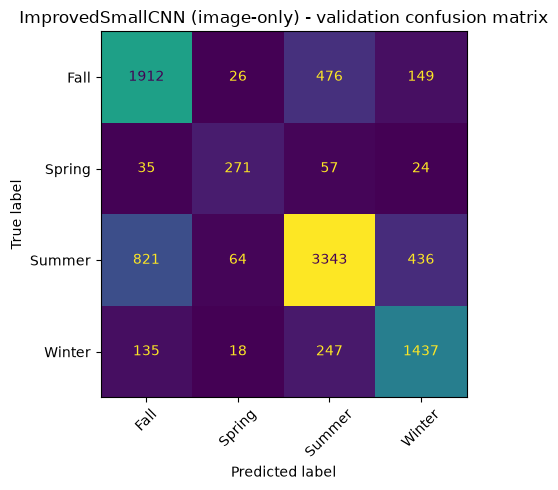

Saved ImprovedSmallCNN (image-only) to ../outputs/task2_models/improved_small_cnn_image_only.pt


In [15]:
# Testing: ImprovedSmallCNN (image-only) -- same treatment as the other baselines above.
improved_small_cnn_img_only_train_f1 = evaluate(improved_small_cnn_img_only_model, image_train_loader)

improved_small_cnn_img_only_model.eval()
improved_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = improved_small_cnn_img_only_model(images).argmax(dim=1).cpu().numpy()
        improved_img_only_val_preds.extend(preds)
improved_img_only_val_preds = np.array(improved_img_only_val_preds)
improved_small_cnn_img_only_val_f1 = f1_score(y_val, improved_img_only_val_preds, average='macro')

print(f'ImprovedSmallCNN (image only) -- train F1: {improved_small_cnn_img_only_train_f1:.4f}, '
      f'val F1: {improved_small_cnn_img_only_val_f1:.4f}\n')
print(classification_report(y_val, improved_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, improved_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ImprovedSmallCNN (image-only) - validation confusion matrix')
plt.tight_layout()
plt.show()

# Saved separately since this (not the multi-input model) is what's actually used for
# the metadata-free test set.
torch.save({
    'model_state_dict': improved_small_cnn_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': improved_small_cnn_img_only_val_f1,
}, OUTPUT_DIR / 'improved_small_cnn_image_only.pt')
print(f'Saved ImprovedSmallCNN (image-only) to {OUTPUT_DIR / "improved_small_cnn_image_only.pt"}')


#### 2. Multi-input model training

MultiInput-ResNet18Pretrained 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8916 - val_loss: 0.9443 - train_f1: 0.6838 - val_f1: 0.6884 - lr: 3.00e-04


MultiInput-ResNet18Pretrained 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained 24/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/70 - train_loss: 0.4079 - val_loss: 0.8143 - train_f1: 0.9781 - val_f1: 0.8242 - lr: 9.37e-06


MultiInput-ResNet18Pretrained 25/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 25/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/70 - train_loss: 0.4077 - val_loss: 0.8226 - train_f1: 0.9775 - val_f1: 0.8241 - lr: 9.37e-06
Early stopping triggered at epoch 25 (best epoch was 10)


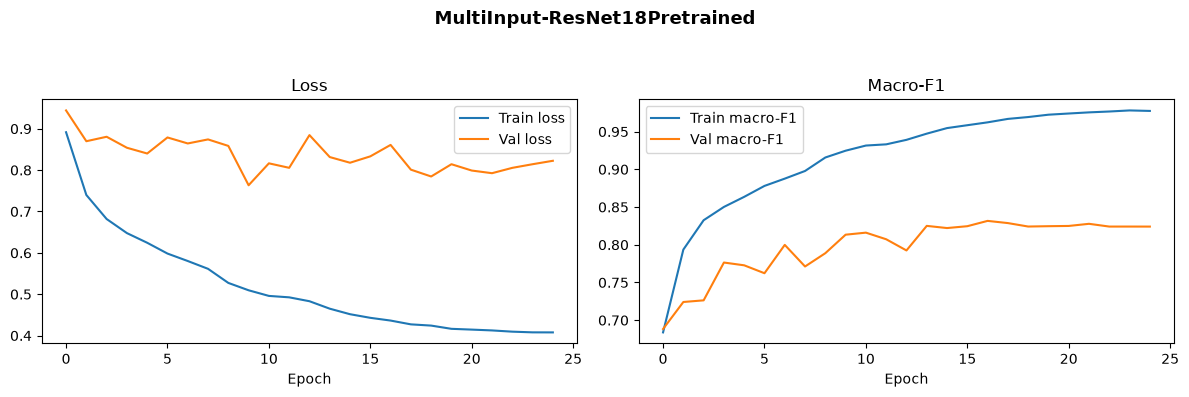

>>> Best checkpoint for MultiInput-ResNet18Pretrained: epoch 10  (val_loss=0.7634, val_f1=0.8134)


In [ ]:
torch.manual_seed(RANDOM_STATE)
resnet_pretrained_model, resnet_pretrained_f1, resnet_pretrained_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader, val_loader, model_name='MultiInput-ResNet18Pretrained')
results['MultiInput-ResNet18Pretrained'] = (resnet_pretrained_f1, resnet_pretrained_epoch)


MultiInput-SmallCNN 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9362 - val_loss: 0.9552 - train_f1: 0.6457 - val_f1: 0.6630 - lr: 3.00e-04


MultiInput-SmallCNN 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-SmallCNN 40/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 40/70 - train_loss: 0.5877 - val_loss: 0.8363 - train_f1: 0.8878 - val_f1: 0.7881 - lr: 1.17e-06


MultiInput-SmallCNN 41/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 41/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 41/70 - train_loss: 0.5849 - val_loss: 0.8797 - train_f1: 0.8877 - val_f1: 0.7787 - lr: 1.17e-06
Early stopping triggered at epoch 41 (best epoch was 26)


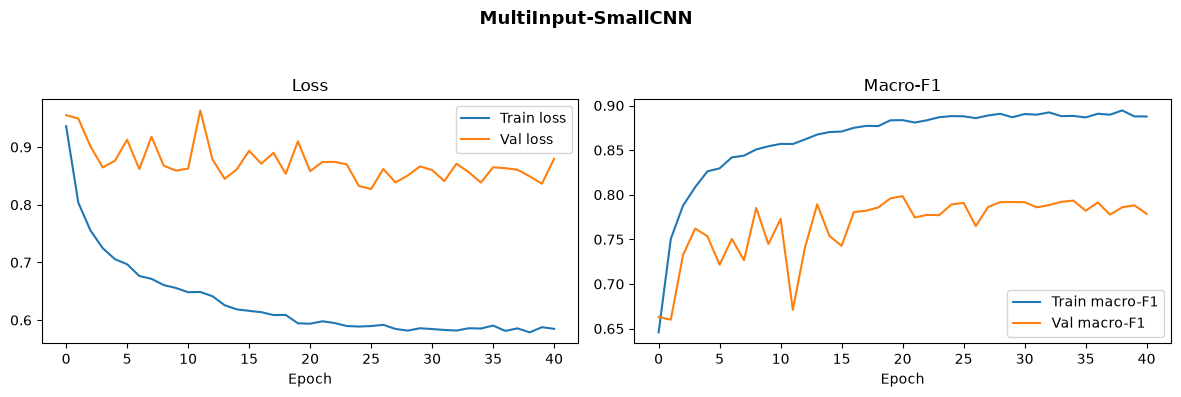

>>> Best checkpoint for MultiInput-SmallCNN: epoch 26  (val_loss=0.8272, val_f1=0.7909)


In [ ]:
torch.manual_seed(RANDOM_STATE)
small_cnn_model, small_cnn_f1, small_cnn_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), SmallImageEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-SmallCNN')
results['MultiInput-SmallCNN'] = (small_cnn_f1, small_cnn_epoch)

MultiInput-ResNet18Scratch 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9280 - val_loss: 0.9864 - train_f1: 0.6573 - val_f1: 0.6680 - lr: 3.00e-04


MultiInput-ResNet18Scratch 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Scratch 24/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/70 - train_loss: 0.4603 - val_loss: 0.8365 - train_f1: 0.9506 - val_f1: 0.8146 - lr: 9.37e-06


MultiInput-ResNet18Scratch 25/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 25/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/70 - train_loss: 0.4597 - val_loss: 0.8229 - train_f1: 0.9518 - val_f1: 0.8145 - lr: 9.37e-06
Early stopping triggered at epoch 25 (best epoch was 10)


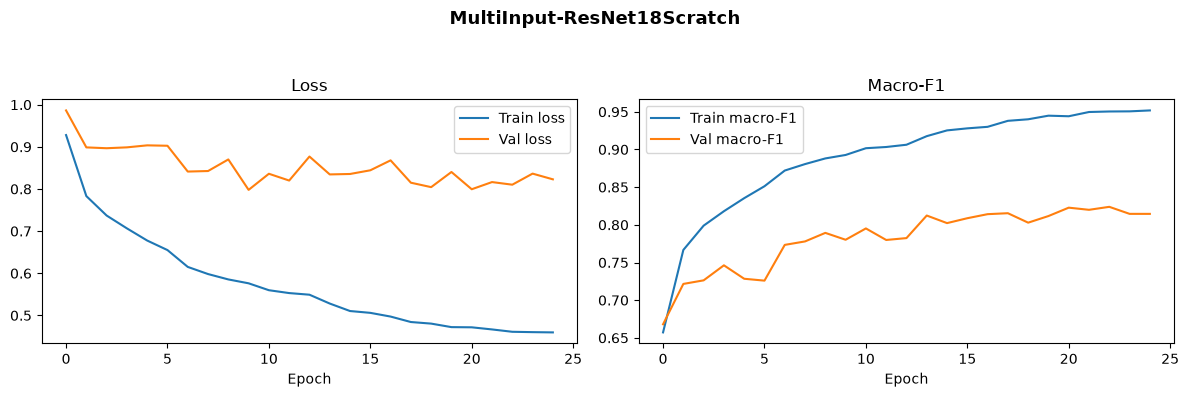

>>> Best checkpoint for MultiInput-ResNet18Scratch: epoch 10  (val_loss=0.7979, val_f1=0.7802)


In [ ]:
torch.manual_seed(RANDOM_STATE)
resnet_scratch_model, resnet_scratch_f1, resnet_scratch_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), ResNet18Encoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-ResNet18Scratch')
results['MultiInput-ResNet18Scratch'] = (resnet_scratch_f1, resnet_scratch_epoch)

MultiInput-ImprovedSmallCNN 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9382 - val_loss: 0.9510 - train_f1: 0.6490 - val_f1: 0.6702 - lr: 3.00e-04


MultiInput-ImprovedSmallCNN 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallCNN 47/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 47/70 - train_loss: 0.5491 - val_loss: 0.8718 - train_f1: 0.9079 - val_f1: 0.8075 - lr: 1.46e-07


MultiInput-ImprovedSmallCNN 48/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 48/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.5467 - val_loss: 0.8327 - train_f1: 0.9091 - val_f1: 0.8030 - lr: 1.46e-07
Early stopping triggered at epoch 48 (best epoch was 33)


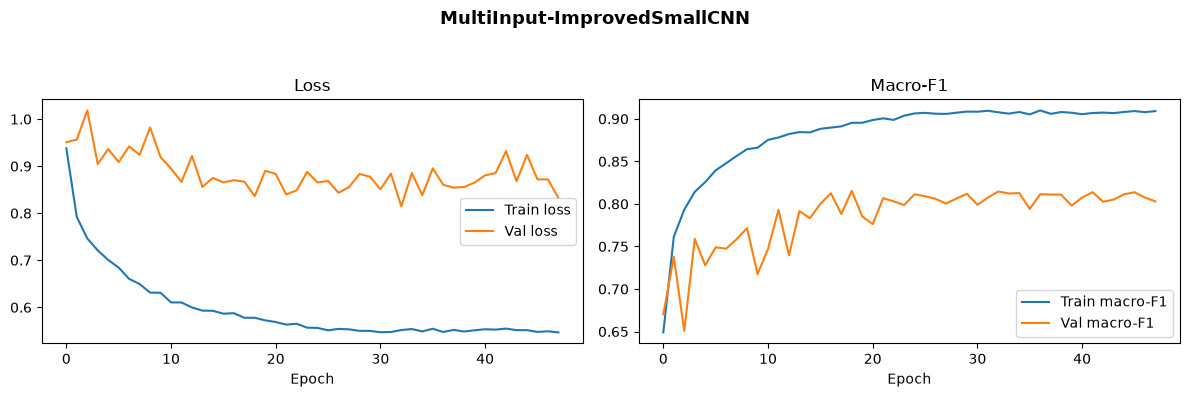

>>> Best checkpoint for MultiInput-ImprovedSmallCNN: epoch 33  (val_loss=0.8146, val_f1=0.8146)


In [ ]:
torch.manual_seed(RANDOM_STATE)

improved_small_cnn_model, improved_small_cnn_f1, improved_small_cnn_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train_final.shape[1], 
        n_classes=len(season_encoder.classes_), 
        image_encoder=ImprovedSmallImageEncoder(out_dim=128)
    ).to(DEVICE), 
    train_loader, 
    val_loader,
    model_name='MultiInput-ImprovedSmallCNN'
)

results['MultiInput-ImprovedSmallCNN'] = (improved_small_cnn_f1, improved_small_cnn_epoch)

MultiInput-SEResidual 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9387 - val_loss: 0.9914 - train_f1: 0.6522 - val_f1: 0.6433 - lr: 3.00e-04


MultiInput-SEResidual 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-SEResidual 36/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 36/70 - train_loss: 0.5987 - val_loss: 0.8551 - train_f1: 0.8799 - val_f1: 0.7923 - lr: 2.34e-06


MultiInput-SEResidual 37/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 37/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 37/70 - train_loss: 0.5997 - val_loss: 0.8410 - train_f1: 0.8832 - val_f1: 0.7946 - lr: 2.34e-06
Early stopping triggered at epoch 37 (best epoch was 22)


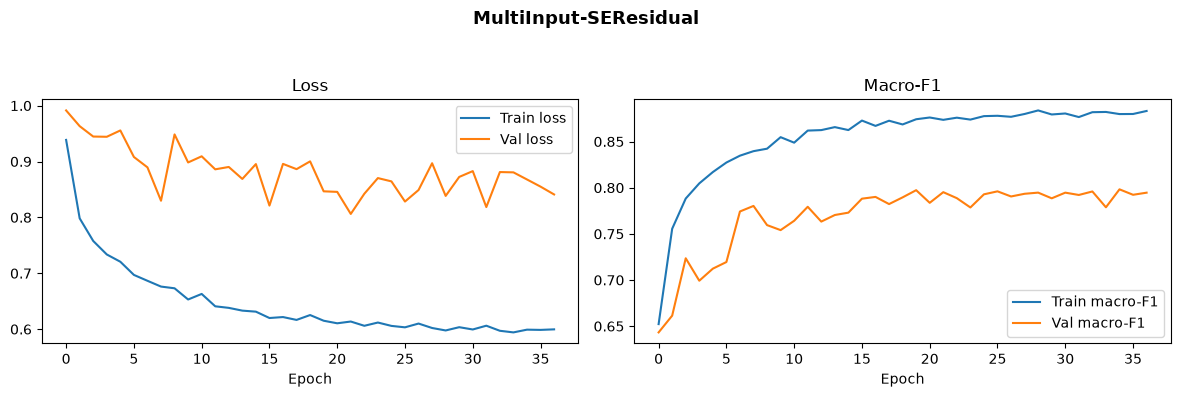

>>> Best checkpoint for MultiInput-SEResidual: epoch 22  (val_loss=0.8062, val_f1=0.7952)


In [ ]:
# MODIFY: new. Multi-input variant on the SE-Residual encoder, so the fusion
# comparison covers the strongest from-scratch encoder too.
torch.manual_seed(RANDOM_STATE)
seres_multi_model, seres_multi_f1, seres_multi_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train_final.shape[1],
        n_classes=len(season_encoder.classes_),
        image_encoder=SEResidualEncoder(out_dim=128)
    ).to(DEVICE),
    train_loader,
    val_loader,
    model_name='MultiInput-SEResidual'
)
results['MultiInput-SEResidual'] = (seres_multi_f1, seres_multi_epoch)


In [ ]:
PRETRAINED_MODELS = {'ResNet18 (pretrained)', 'MobileNetV3-Small (pretrained)', 'MultiInput-ResNet18Pretrained'}
saveable_results = {k: v for k, v in results.items() if k not in PRETRAINED_MODELS}

best_name = max(saveable_results, key=lambda k: saveable_results[k][0])
best_f1, best_epoch_num = saveable_results[best_name]

print('=== Early-stopping checkpoint summary ===')
for name, (f1, epoch) in sorted(results.items(), key=lambda kv: -kv[1][0]):
    if name == best_name:
        marker = '  <-- best (saveable)'
    elif name in PRETRAINED_MODELS:
        marker = '  (pretrained -- excluded from saving)'
    else:
        marker = ''
    print(f'{name:35s}  val_f1={f1:.4f}  (best epoch: {epoch}){marker}')

print(f'\nBest performing SAVEABLE model: {best_name} (val_f1={best_f1:.4f} at epoch {best_epoch_num})')

=== Early-stopping checkpoint summary ===
MultiInput-ImprovedSmallCNN          val_f1=0.8146  (best epoch: 33)  <-- best (saveable)
MultiInput-ResNet18Pretrained        val_f1=0.8134  (best epoch: 10)  (pretrained -- excluded from saving)
MultiInput-SEResidual                val_f1=0.7952  (best epoch: 22)
MultiInput-SmallCNN                  val_f1=0.7909  (best epoch: 26)
MultiInput-ResNet18Scratch           val_f1=0.7802  (best epoch: 10)
ResNet18 (pretrained)                val_f1=0.7551  (best epoch: 19)  (pretrained -- excluded from saving)
ImprovedSmallCNN (image-only)        val_f1=0.7271  (best epoch: 30)

Best performing SAVEABLE model: MultiInput-ImprovedSmallCNN (val_f1=0.8146 at epoch 33)


In [ ]:
# Evaluate both splits and compare all models
multi_train_loader = DataLoader(
    MultiInputDataset(task2_train, meta_train_final, y_train, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

multi_val_loader = DataLoader(
    MultiInputDataset(task2_val, meta_val_final, y_val, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

scores = pd.DataFrame({
    'Train F1': [
        logreg_train_f1,
        resnet_train_f1,
        improved_small_cnn_img_only_train_f1,
        evaluate(small_cnn_model, multi_train_loader),
        evaluate(improved_small_cnn_model, multi_train_loader),
        evaluate(resnet_scratch_model, multi_train_loader),
        evaluate(resnet_pretrained_model, multi_train_loader),
    ],
    'Validation F1': [
        logreg_val_f1,
        resnet_val_f1,
        improved_small_cnn_img_only_val_f1,
        evaluate(small_cnn_model, multi_val_loader),
        evaluate(improved_small_cnn_model, multi_val_loader),
        evaluate(resnet_scratch_model, multi_val_loader),
        evaluate(resnet_pretrained_model, multi_val_loader),
    ]

}, index=[
    'Logistic Regression',
    'ResNet18 (pretrained)',
    'ImprovedSmallCNN (image-only)',
    'MultiInput-SmallCNN',
    'MultiInput-ImprovedSmallCNN',
    'MultiInput-ResNet18Scratch',
    'MultiInput-ResNet18Pretrained',
])

display(scores.round(4))

,Train F1,Validation F1
Logistic Regression,0.7459,0.7286
ResNet18 (pretrained),0.9449,0.7551
ImprovedSmallCNN (image-only),0.8724,0.7271
MultiInput-SmallCNN,0.8323,0.7909
MultiInput-ImprovedSmallCNN,0.8836,0.8146
MultiInput-ResNet18Scratch,0.8582,0.7802
MultiInput-ResNet18Pretrained,0.9161,0.8134


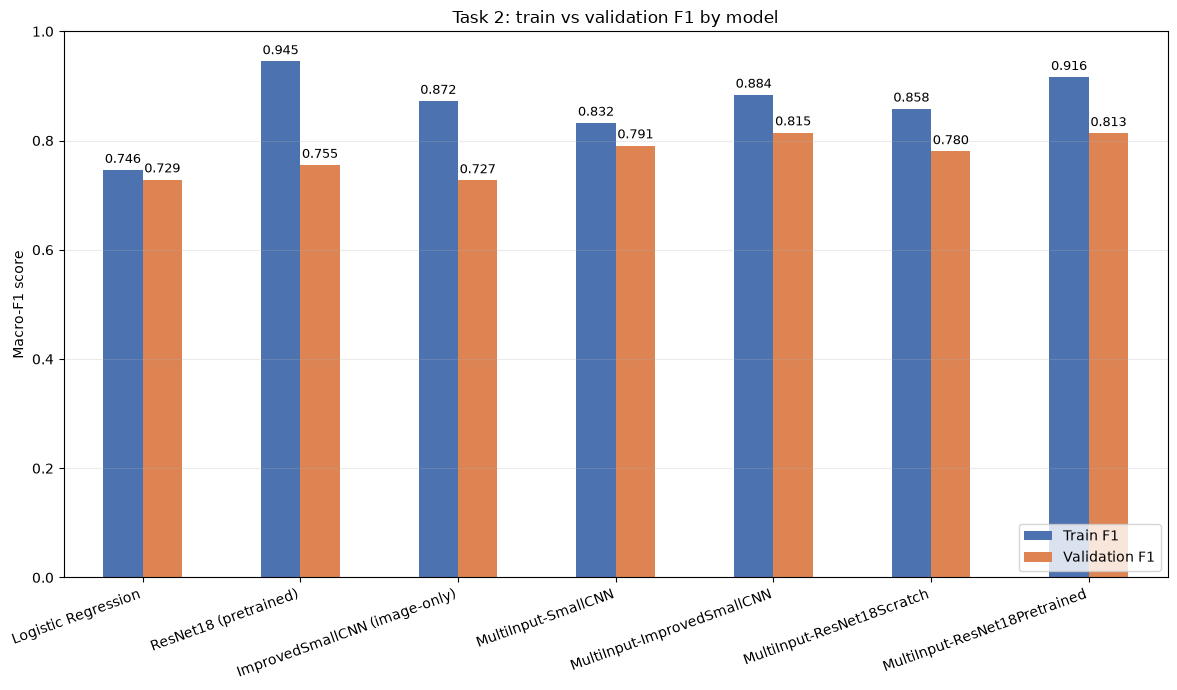

In [26]:
ax = scores.plot(kind='bar', figsize=(12, 7), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score'); plt.title('Task 2: train vs validation F1 by model'); plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

### Saving the best multi-input model
The models are saved to later loaded into a pipeline to generate metadata and do prediction on test set using multi-input model

In [ ]:
# MODIFY: new. Selects and saves the best FROM-SCRATCH multi-input model.
multi_input_candidates = {
    'MultiInput-SmallCNN': (small_cnn_model, small_cnn_f1, SmallImageEncoder),
    'MultiInput-ResNet18Scratch': (resnet_scratch_model, resnet_scratch_f1, ResNet18Encoder),
    'MultiInput-ImprovedSmallCNN': (improved_small_cnn_model, improved_small_cnn_f1, ImprovedSmallImageEncoder),
    'MultiInput-SEResidual': (seres_multi_model, seres_multi_f1, SEResidualEncoder),
}

print('Multi-input candidates (validation macro-F1, from-scratch only):')
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f'  {name:32s} {f1_val:.4f}')

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_encoder_cls = multi_input_candidates[best_multi_name]
print(f'\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})')
print(f'>>> For reference, the pretrained variant scored '
      f'{resnet_pretrained_f1:.4f} -- excluded from selection by the assignment rule.')

torch.save({
    'model_state_dict': best_multi_model.state_dict(),
    'model_name': best_multi_name,
    'image_encoder': best_multi_encoder_cls.__name__,
    'metadata_dim': int(meta_train_final.shape[1]),
    'n_classes': int(len(season_encoder.classes_)),
    'out_dim': 128,
    'val_f1': float(best_multi_f1),
    'pretrained': False,
}, OUTPUT_DIR / 'best_multiinput_task2.pt')

joblib.dump(meta_preprocessor, OUTPUT_DIR / 'meta_preprocessor_task2.joblib')

# Reload check -- confirms the checkpoint reconstructs into a working model.
ckpt = torch.load(OUTPUT_DIR / 'best_multiinput_task2.pt', map_location=DEVICE)
reloaded = MultiInputNet(ckpt['metadata_dim'], ckpt['n_classes'],
                         best_multi_encoder_cls(out_dim=ckpt['out_dim'])).to(DEVICE)
reloaded.load_state_dict(ckpt['model_state_dict'])
print('Reload check: state dict loads cleanly into a fresh model.')
print('Saved:', OUTPUT_DIR / 'best_multiinput_task2.pt')
print('Saved:', OUTPUT_DIR / 'meta_preprocessor_task2.joblib',
      '(needed to rebuild the metadata vector at inference time)')


Multi-input candidates (validation macro-F1, from-scratch only):
  MultiInput-ImprovedSmallCNN      0.8146
  MultiInput-SEResidual            0.7952
  MultiInput-SmallCNN              0.7909
  MultiInput-ResNet18Scratch       0.7802

>>> Best multi-input model: MultiInput-ImprovedSmallCNN (val macro-F1 = 0.8146)
>>> For reference, the pretrained variant scored 0.8134 -- excluded from selection by the assignment rule.
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task2_models/best_multiinput_task2.pt
Saved: ../outputs/task2_models/meta_preprocessor_task2.joblib (needed to rebuild the metadata vector at inference time)
